# Vorhersage der Feuerwiderstandsdauer von faserverstärkten Betonträgern

## Abschlussprojekt zum Kurs Data Scientist 2025-2 der IHK Rhein-Neckar (kondensierte Fassung)

**Kurslaufzeit** vom 27.11.2025 bis zum 14.02.2026, berufsbegleitend  
**Bearbeitungszeit**: 2 Wochen  
**Ausarbeitung** von [Benedikt Pöschl](https://www.linkedin.com/in/benepoeschl)  
**Nutzung** nur im Rahmen des Kurses  

**Quellen**:  
[1] 📄 **Paper**: [Dataset on fire resistance analysis of FRP-strengthened concrete beams (Bhatt et al., 2024)](https://doi.org/10.1016/j.dib.2024.110031)  
[2] 📊 **Daten**: [Bhatt, Pratik (2023), “Fire Resistance of FRP-Strengthened Beams”, Mendeley Data, V6](https://data.mendeley.com/datasets/3c2szhbdn5/6)

## Aufgabenstellung des Abschlussprojekts

Gefordert war der eigenständige Aufbau einer vollständigen Data-Science-Pipeline mit einem Businesscase im Hintergrund.
Die Arbeitsschritte sollten alles von der EDA und Data Preprocessing (Umgang mit fehlenden Werten, Outlier Detection) über Feature Engineering und Modellauswahl bis hin zum Hyperparameter-Tuning und einer Kreuzvalidierung (Cross-Validation) sowie abschließender Evaluation beinhalten. Empfohlen wurden hierfür etablierte Standard-Szenarien wie die Vorhersage von Immobilienpreisen (Housing Prices) oder Kundenabwanderung (Churn Prediction).  

Anstatt auf bereinigte Standard-Datensätze zurückzugreifen, wurde für diese Arbeit bewusst ein hochkomplexer, praxisnaher Use-Case aus dem Bauingenieurwesen gewählt: Die Vorhersage der Feuerwiderstandsdauer von faserverstärkten Betonträgern.  

Üblicherweise spricht man beim Arbeitsaufwand von einer Aufteilung von etwa 80% Preprocessing und 20% für den Rest. Insbesondere im gewählten Kontext sehe ich die notwendige Aufteilung als 45% domain-driven Preprocessing, 20% Modell-Architektur und 35% Evaluierung und Plausibilisierung.  

## Business Case

Im konstruktiven Brandschutz entscheidet die Feuerwiderstandsdauer von tragenden Bauteilen im Ernstfall über Menschenleben. Die traditionelle Bemessung von Stahlbetonbalken stützt sich auf konservative Tabellenwerte oder auf zeitintensive numerische Simulationen. Während Erstere bisweilen unwirtschaftlich sein können, erfordern Letztere tiefgreifendes Expertenwissen und hohe Zeit- und Rechenkapazitäten.  

Die Entwicklung präziser Vorhersagemodelle steht im konstruktiven Brandschutz vor der klassischen Hürde des "Small Data" im Ingenieurwesen, unter anderem da Brandversuche kostenbedingt auf das Nötigste beschränkt werden. In diesem Projekt stehen 50 reale Versuchsdatensätze einer Masse von mehr als 20.000 synthetischen Simulationsdaten gegenüber. Weiterhin sind Laborversuche oft "rechtszensiert". Das bedeutet viele Tests enden planmäßig bevor das untersuchte Bauteil tatsächlich versagt, was herkömmliche Regressionsmodelle systematisch verzerrt.  

Wie die minutengenaue Vorhersage in dieser Ausarbeitung zeigt, haben Machine-Learning Modelle das Potential, um mit entsprechenden Daten durch die Vorhersagen die Versuchsplanung zu unterstützen, Versuche kosteneffizienter zu gestalten oder langfristig als ergänzendes Werkzeug in der Bemessung eingesetzt zu werden.

### Disclaimer

Ziel dieses Abschlussprojekts soll die Entwicklung eines Machine-Learning Modells sein, das das Domänenwissen eines Bauingenieurs mit dem eines Data Scientists verbindet und die Kursinhalte aufgreift. Der Fokus liegt somit nicht vorrangig auf der ingenieurmäßigen Bewertung bzw. Interpretation der Ergebnisse.

Da die Quellen [1, 2] wenig Informationen zu den Daten selbst bzw. deren Zustandekommen enthalten, die referenzierte Literatur teilweise nicht frei zugänglich ist und auch der Bearbeitungszeitraum für eine extensive Literaturrecherche zu knapp bemessen ist, wird mit dieser vergleichsweise geringen Informationsdichte gearbeitet. Das hier erarbeitete Modell dient lediglich akademischen Demonstrationszwecken im Rahmen des Abschlussprojekts für den genannten Kurs und darf nicht anderweitig eingesetzt werden. Für den realen Einsatz müssten mindestens die Anwendungsgrenzen erarbeitet, Validierungsversuche durchgeführt und jeglicher Bias transparent herausgestellt werden.  

Der Autor übernimmt daher keine Haftung für Schäden, die aus einer unsachgemäßen Verwendung oder dem Vertrauen auf die Modellergebnisse resultieren. Die Nutzung des Modells wie auch damit erzielte Ergebnisse erfolgen auf eigene Gefahr.

## Inhalte

- Data Challenge:
    - Nichtlineare Korrelationen
    - Imbalanced Data
    - Rechtszensur
    - Vorhandener Bias:
        - Selection & Sampling
        - Measurement
        - Design / Confounding
        - Simulation / Model
        - Feature

- Lösungsstrategie:
    - Umfassende EDA (Exploratory Data Analysis)
    - Preprocessing
        - Data Cleaning
        - Feature Engineering und Reverse Engineering
        - Feature Reduction
    - Modell Architektur mit XGBoost:
        - Custom Splits & Sample Weights (für Imbalanced Data)
        - Custom Objective Function (für Rechtszensur)
        - Monotonic Constraints (für Overfitting)
    - Optimierung:
        - Optuna (Hyperparameter Tuning & automatische Feature Selection)
    - Evaluierung & Interpretation:
        - Custom Scoring
        - SHAP-Analyse

- Fazit

## Konzeptioneller Versuchsaufbau

![Konzeptioneller Versuchsaufbau](Konzept_Versuchsaufbau.png)

Im Bild ist vereinfacht der Versuchsaufbau und Ablauf dargestellt:
- Das Koordinatensystem wird definiert als: x-Achse in Balkenlängsrichtung (positiv nach rechts), z-Achse nach unten, y-Achse senkrecht aus der Ebene heraus
- Ein Balken wird gelenkig aufgelagert, sodass die Verdrehung am Auflager um die y-Achse nicht behindert wird
- Es wird eine Last über zwei Einleitungspunkte aufgebracht (Vierpunktbiegeversuch) und konstant gehalten
- Biegt sich der Balken durch die Last nicht mehr durch, wird der Balken dreiseitig beflammt (auf den Seiten y+, y- und z+)
- Durch temperaturinduzierte Effekte biegt sich der Balken weiter durch
- Der Versuch endet, wenn der Balken versagt (bspw. Biegebruch), eine Grenzverformung erreicht ist oder wenn der Zielwert der Feuerwiderstandsdauer erreicht wird (Rechtszensur)

## Beschreibung der Daten

### Allgemeines

Der Datensatz enthält Daten zum Feuerwiderstand von faserverstärkten (FRP) Stahlbetonbalken. Die Daten bestehen aus variierenden geometrischen Abmessungen, Faseranteilen, Bewehrungsmengen, Dämmdicken sowie Materialparametern als auch Lasthöhen, siehe [1].  
Die verlinkte Excel-Datei [2] setzt sich aus mehreren Arbeitsblättern zusammen. Im Blatt `01_FireTestData` sind die Daten aus 50 Laborversuchen hinterlegt, die *Bhatt et al.* teilweise selbst durchgeführt wie auch aus der Literatur zusammengetragen haben. Der zweite Datensatz befindet sich im Blatt `02_NumericaModelData`, welches die synthetischen Daten enthält (21384 Einträge), die anhand von Finite-Elemente-Berechnungen erzeugt wurden.  

Aufgrund der Brandsituation ergeben sich hoch nichtlineare Zusammenhänge zwischen den Eingangsgrößen und der Feuerwiderstandsdauer als gewählte Zielvariable.

Weiterhin ist darauf zu achten, dass den Daten verschiedene Biases zugrundeliegen. Diese resultieren einerseits aus den Versuchsaufbauten und -verfahren wie auch aus den Modellannahmen und der Parameterwahl zur Erzeugung der realen und synthetischen Daten. Weiterhin unterliegen die veröffentlichen Daten bereits einem Feature-Engineering von *Bhatt et al.*, wodurch die angegebenen Parameter bereits meinungsbehaftet sind. Die Rohdaten wie auch Angaben dazu, welche Beobachtung aus welcher Veröffentlichung stammt, ist nicht im Datensatz hinertlegt. Ebenso fehlen direkte Angaben zu wichtigen Informationen, wie bspw. zu den zugrundeliegenden Brandparametern (überall ETK? überall dreisitige Beflammung? gleiche Materialkennwerte für Beton?) oder auch zum Versuchsaufbau und -ablauf. Diese werden für die Laborversuche untereinander als gleichwertig unterstellt, da eine ausgiebiege Literaturrecherche im Kontext des Abschlussprojekts unzumutbar ist.

### Data Challenge

Im Gegensatz zu den üblichen Datensätzen für Abschlussprojekte (bspw. Titanic oder Housing Prices) wurde ein thematisch als auch inhaltlich komplexer Datensatz gewählt. Für den Bereich Data Science sind die Herausforderungen nachfolgend gelistet.

#### Nonlinearity und Data Imbalance

- nichtlineare Korrelationen aus Temperatureinwirkung
- Beobachtungen aus Versuchen:      50
- Beobachtungen aus Simulation: > 20.000

#### Biases

- **Selection & Sampling Bias**: Auswahlverzerrung durch Begrenzung auf gleichartige Balkenkonfigurationen  
- **Measurement Bias**: systematische Verfälschung von Daten durch Rechtszensur (vorzeitiges Versuchsende)  
- **Design / Confounding Bias**: unabhängige Variablen werden künstlich miteinander korreliert  
- **Simulation / Model Bias**: Annahmen zum numerischen Modell bei der Finite-Elemente-Berechnung  
- **Feature Bias**: durch Veröffentlichung tansformierter / aggregierter Daten statt Rohdaten  

### Beschreibung der Daten

#### Realdaten

Die Realdaten setzen sich aus den folgenden Spalten zusammen, die für die Lesbarkeit bereits umbenannt wurden. An Spalten mit (pyhsikalischen) Einheiten wurden diese angehängt. Es handelt sich hierbei um die Einheiten, wie sie in den Headern der Excel-Datei [2] angegeben sind.

##### Tabelle 1: Parameter der Realdaten


| Parameter                                 | Bezeichnung |
|---                                        |---|
| beam_number                               | Identifikation der Beobachtung (⚠️ 2x B45 für versch. Beobachtungen)  |
| beam_length__m                            | Länge des Balkens in m  |
| concrete_area__mm2                        | Brutto-Fläche des Betonquerschnitts in mm²  |
| concrete_cover__mm                        | Betondeckung in mm  |
| steel_area__mm2                           | Fläche der Bewehrung in mm² (im Zugbereich) |
| frp_area__mm2                             | Fläche der Faserverstärkung in mm²  |
| insulation_thickness__mm                  | Dicke der Dämmung in mm  |
| insulation_depth__mm                      | Höhe der seitlichen Dämmung in mm  |
| concrete_compr_strength__MPa              | Festigkeit des Betons in MPa  |
| steel_yield_strength__MPa                 | Streckgrenze des Betonstahls in MPa  |
| steel_youngs_modulus__MPa                 | Elastizitätsmodul des Betonstahls in MPa  |
| frp_tens_strength__MPa                    | Zugfestigkeit der Faserverstärkung in MPa  |
| frp_youngs_modulus__MPa                   | Elastizitätsmodul der Faserverstärkung in MPa  |
| transition_temp_glass__deg                | Temperatur für den Glasübergang in °C <br/>(Temperatur ab dem sich der Verbund der Faserverstärkung löst)  |
| insulation_thermal_conductivity__W_per_mK | Wärmeleitfähigkeit der Dämmung in W/(m K)  |
| insulation_specific_heat_cap__J_per_degm3 | Spezifische Wärmekapazität in J/(°C m³)  |
| total_load__kN                            | Gesamtbelastung, die auf die Balken aufgebracht wurde in kN  |
| load_ratio__percent                       | Lastverhältnis / Ausnutzung in Prozent (Anteil der maximalen Tragfähigkeit im <br/>Kaltfall, die als Last für den Versuch aufgebracht wurde)  |
| test_end_criterion                        | Das Kriterium, weswegen der Versuch beendet wurde <br/>(0: Versagen, 1: Ende der Brandbeanspruchung)  |
| fire_resistance__min                      | Die Feuerwiderstandsdauer in Minuten  |
| deflection_at_failure__mm                 | Das Maß der Durchbiegung (in Balkenmitte) zum Versuchsende in mm  |

#### Synthetische Daten

Die synthetischen Daten setzen sich aus den folgenden Spalten zusammen, die für die Lesbarkeit bereits umbenannt wurden. An Spalten mit pyhsikalischen Einheiten wurden diese angehängt. Es handelt sich hierbei um die Einheiten, wie sie in den Headern der Excel-Datei [2] angegeben sind.

##### Tabelle 2: Parameter der synthetischen Daten

| Parameter                                     | Bezeichnung  |
|---                                            |---|
| beam_number                                   | Identifikation der Beobachtung  |
| beam_length__mm                               | Länge des Balkens in **mm** ⚠️ |
| concrete_area__mm2                            | Brutto-Fläche des Betonquerschnitts in mm²  |
| concrete_cover__mm                            | Betondeckung in mm  |
| steel_area__mm2                               | Fläche der Bewehrung in mm² (im Zugbereich) |
| frp_area__mm2                                 | Fläche der Faserverstärkung in mm²  |
| insulation_thickness__mm                      | Dicke der Dämmung in mm  |
| insulation_depth__mm                          | Höhe der seitlichen Dämmung in mm  |
| concrete_compr_strength__MPa                  | Festigkeit des Betons in MPa  |
| steel_yield_strength__MPa                     | Streckgrenze des Betonstahls in MPa  |
| steel_youngs_modulus__MPa                     | Elastizitätsmodul des Betonstahls in MPa  |
| frp_tens_strength__MPa                        | Zugfestigkeit der Faserverstärkung in MPa  |
| frp_youngs_modulus__MPa                       | Elastizitätsmodul der Faserverstärkung in MPa  |
| transition_temp_glass__deg                    | Temperatur für den Glasübergang in °C <br/>(Temperatur ab dem sich der Verbund der Faserverstärkung löst)  |
| insulation_thermal_conductivity__W_per_mmdeg  | Wärmeleitfähigkeit der Dämmung in **W/(mm °C**) ⚠️ |
| insulation_specific_heat_cap__J_per_degmm3    | Spezifische Wärmekapazität in **J/(°C mm³**) ⚠️ |
| total_load__kN                                | Gesamtbelastung, die auf die Balken aufgebracht wurde in kN  |
| load_ratio__percent                           | Lastverhältnis / Ausnutzung in Prozent (Anteil der maximalen Tragfähigkeit <br/>im Kaltfall, die als Last für den Versuch aufgebracht wurde)  |
| test_end_criterion                            | Das Kriterium, weswegen der Versuch beendet wurde <br/>(0: Versagen, 1: Ende der Brandbeanspruchung)  |
| fire_resistance__min                          | Die Feuerwiderstandsdauer in Minuten  |
| deflection_at_failure__mm                     | Das Maß der Durchbiegung (in Balkenmitte) zum Versuchsende in mm  |
| *limit_state*                                 | Bezeichnung des Versagens (*Durchbiegung*, *Bruch*, *kein Versagen*, <br/>wobei kein Versagen das Erreichen der Endzeit von 300 Minuten bedeutet)  |
| *initial_capacity__kNm*                       | th. Momententragfähigkeit im Kaltfall in kNm  |
| *final_capacity__kNm*                         | th. Momententragfähigkeit bei Versuchsende in kNm  |


## 1. Exploratory Data Analysis (EDA)

In [51]:
# pip install -r requirements.txt

In [52]:
# INITIAL SETTINGS
import pandas as pd
from outsourced import CBF_THEME
from matplotlib.colors import LinearSegmentedColormap

# PANDAS
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# MATPLOTLIB
mpl_theme = CBF_THEME
mpl_theme.apply()
mpl_palette = LinearSegmentedColormap.from_list(
    "cbf_palette", [mpl_theme.primary_color, mpl_theme.secondary_color, mpl_theme.tertiary_color]
) #"flare"

In [53]:
# CHECK FOR FILE
from outsourced import check_for_dataset
check_for_dataset()

### Laden der Daten

In [54]:
from outsourced import load_real_data, load_synth_data

# Daten laden
df_real = load_real_data()
df_synth = load_synth_data()

# Ausgabe Anzahl Beobachtungen vs Parameter
print("shape real: ", df_real.shape)
print("shape synth: ", df_synth.shape)

shape real:  (50, 21)
shape synth:  (21384, 24)


#### Tabelle 3: Allgemeine statistische Kenngrößen der Realdaten

In [55]:
df_real.describe().round(2).transpose()

,count,mean,std,min,25%,50%,75%,max
beam_length__m,50.0,2.86,1.24,1.26,1.50,3.00,3.66,6.00
concrete_area__mm2,50.0,55169.96,38616.47,12000.00,12000.00,45000.00,90000.00,125730.00
concrete_cover__mm,50.0,21.08,8.23,10.00,15.00,19.00,25.00,38.00
steel_area__mm2,50.0,319.90,279.63,56.55,56.55,157.10,402.10,942.50
frp_area__mm2,50.0,67.83,72.68,0.00,28.00,60.00,76.50,460.00
insulation_thickness__mm,50.0,21.71,16.39,0.00,0.38,25.00,34.25,50.00
insulation_depth__mm,50.0,119.70,158.17,0.00,0.00,0.00,275.00,500.00
concrete_compr_strength__MPa,50.0,36.74,8.11,23.00,30.10,37.00,44.38,52.00
steel_yield_strength__MPa,50.0,503.22,69.33,364.00,452.50,500.00,546.00,591.00
steel_youngs_modulus__MPa,50.0,200304.10,29650.49,205.00,200000.00,207500.00,210000.00,210000.00


#### Tabelle 4: Anteile der Abbruchkriterien der Realdaten (0: Versagen, 1: Ende Brand)

In [56]:
from outsourced import get_value_counts
get_value_counts(df_real, "test_end_criterion")

,Anzahl,Anteil
test_end_criterion,,
1,31,62.0
0,19,38.0


In Tabelle 4 wird die enorme Anteil der Rechtszensur im Datensatz offenkundig. 62% Der Daten sind rechtszensiert und liefern damit lediglich eine Aussage über einen möglichen Mindestwert der Feuerwiderstandsdauer. 

#### Tabelle 5: Allgemeine statistische Kenngrößen der synthetischen Daten

In [57]:
df_synth.describe().round(2).transpose()

,count,mean,std,min,25%,50%,75%,max
beam_length__mm,21384.0,3362.63,1466.07,1220.00,2000.00,3160.00,4700.00,6200.00
concrete_area__mm2,21384.0,88493.18,41606.54,12000.00,57500.00,90000.00,122500.00,157500.00
concrete_cover__mm,21384.0,26.45,9.72,10.00,23.50,25.00,38.00,38.00
steel_area__mm2,21384.0,400.65,205.61,63.31,243.39,387.88,569.76,854.64
frp_area__mm2,21384.0,118.23,103.12,0.00,39.60,91.80,163.20,629.30
insulation_thickness__mm,21384.0,25.28,10.53,-2.03,19.00,25.00,38.00,38.00
insulation_depth__mm,21384.0,41.64,35.28,0.00,0.00,38.00,75.00,114.00
concrete_compr_strength__MPa,21384.0,33.49,4.06,27.00,30.00,33.00,37.00,40.00
steel_yield_strength__MPa,21384.0,436.57,13.60,414.00,424.00,436.00,448.00,460.00
steel_youngs_modulus__MPa,21384.0,204985.50,4089.42,200000.00,200000.00,205000.00,210000.00,210000.00


#### Tabelle 6: Anteile der Abbruchkriterien der synthetischen Daten

In [58]:
from outsourced import get_value_counts
get_value_counts(df_synth, "limit_state")

,Anzahl,Anteil
limit_state,,
Deflection Failure,18472,86.38
Strength Failure,2431,11.37
No Failure,481,2.25


In Tabelle 6 sieht man, dass 2% der synthetischen Daten rechtszensiert sind. Weiterhin wird eine Unterscheidung der Versagensart getroffen, die in den Daten zu den Laborversuchen nicht ersichtlich ist.

### Plots zu Realdaten

#### Parameterverteilung der Realdaten

In [59]:
from outsourced import plot_distribution

plot_distribution(
    df=df_real,
    fig_pre="Abbildung 1-1.",
    title="Verteilung der Parameter der Realdaten",
    theme=mpl_theme,
)

**Verteilungsplots**:  
- Viele Parameter zeigen einzelne Spitzen. Das deutet darauf hin, dass es wenige Parametergruppen gibt. Bei den zusammengetragenen Laborversuchen wurden also jeweils im wesentlichen die gleichen Randbedingungen angesetzt und einige wenige Änderungen für spezifische Parameter untersucht.
- Es gibt eine deutliche Häufung bei den Feuerwiderstandsdauern um die 100 Minuten sowie um die 180 Minuten. Die größere Fläche unter der orangen Kurve zeigt deutlich, dass mehr Versuche planmäßig beendet wurden (Rechtszensur), als dass ein Versagen beobachtet wurde. Die planmäßig beendeten Versuche häufen sich bei um die 50 bis 90 Minuten.

#### Scatterplot der Realdaten

In [60]:
from outsourced import scatter_data

# temporary dataframe for scatter plot with slenderness as "hue column"
df_scatter = df_real.copy()
df_scatter["slenderness__1_per_mm"] = (
    df_scatter["beam_length__m"] * 1000 / df_scatter["concrete_area__mm2"]
).round(2)

scatter_data(
    df=df_scatter,
    fig_pre="Abbildung 1-2.",
    title="Scatterplots der Parameter der Realdaten",
    hue_col="slenderness__1_per_mm",
    style_col="test_end_criterion",
    theme=mpl_theme,
    markers={0: "X", 1: "o"},
    palette=mpl_palette,
)

**Scatterplots**:  
- Bei den Scatterplots sieht man vor allem in den geometrischen Parametern einen ansatzweise linearen Einfluss auf die Feuerwiderstandsdauer. Das macht insofern Sinn, da massigere Bauteile sich weniger aufheizen, üblicherweise mehr Stahl enthalten und dadurch größere Feuerwiderstandsdauern aufweisen.
- Andere Tendenzen lassen sich bspw. noch bei der Belastung ablesen (Abb. 1-2.16), was aber auch damit zusammenhängt, dass mehr Last auf die größeren Bauteile aufgebracht werden kann.
- In den Scatterplots erkennt man bereits potenzielle Ausreißer, wie bspw. in Abb. 1-2.5 (große FRP Fläche), Abb. 1-2.10 (sehr geringer E-Modul für Stahl), Abb. 1-2.12 (sehr großer E-Modul für FRP), Abb. 1-2.14 und 1-2.15 (hohe thermische Eigenschaften) und Abb. 1-2.17 (einige geringe Lastverhältnisse) sowie 1-2.21 (lange Feuerwiderstandsdauer bei hoher Schlankheit).

#### Barplots mit z-Score für Realdaten

In [61]:
from outsourced import plot_radial_zscore

om = plot_radial_zscore(
    df=df_real,
    title="Abbildung 1-3: Outlier-Analyse mit Z-Score (Realdaten)",
    label_col="", #"beam_number",
    theme=mpl_theme,
    use_curved_text=True,
    text_scale=0.05,
    use_text_offset=True,
)
p = sum(om) / len(om) * 100
print(f"Anteil pot. Ausreißer {p:.2f}%")

Anteil pot. Ausreißer 52.00%


**Barplots**:  
- In den Barplots (mit z-Score und Outlier per IQR) wird besonders deutlich, dass es einige potentielle Ausreißer gibt.
- Einige der Ausreißer machen Sinn, wie bei der Glasübergangstemperatur (transition_temp_glass_deg), da hier, wie bei allen Parametern für FRP, eine 0 dafür steht, dass bei der Beobachtung kein FRP eingesetzt wurde.
- Viele Ausreißer haben aber keine physikalische bzw. verfahrenstechnische Erklärung und sind schlicht Fehler im Datensatz (bspw. ein E-Modul von 205 *MPa* von Bewehrungsstahl statt 205 *GPa*)

#### Korrelations-Heatmap für Realdaten

In [62]:
from outsourced import plot_heatmap

plot_heatmap(
    df_real.drop(["beam_number"], axis=1),
    title="Abbildung 1-4: Korrelationsmatrix für reale Daten",
    theme=mpl_theme,
    palette=mpl_palette
)

**Heatmap für Korrelation**:  
- Hier sieht man einige voneinander abhängige Größen. Viele Werte hängen mit den geometrischen Größen zusammen, was sowohl physikalisch als auch versuchstechnisch zu erklären ist (bspw. wie zuvor: besserer Querschnitt => höhere Feuerwiderstandsdauer, besserer Querschnitt => höhere Belastung).
- Physikalisch keinen Sinn macht die negative Korrelation zwischen E-Modul des Stahls zu den Geometrie-Parametern. Die Erklärung lässt sich bspw. aus den Scatterplots Abb. 1-2.10 und 1-2.9 ableiten. Durch die Einfärbung nach der `Schlankheit` erkennt man, dass je tragfähiger ein Balken ist (Korreltaion zur Geometrie) umso schlechterer Stahl ist eingebaut worden (geringere Zugfestigkeit). Das heißt die negative Korrelation ergibt sich hier durch die Versuchsplanung bzw. Zusammenstellung der Versuchsdaten.
- Die starke negative Korrelation von Geometrie zur Durchbiegung ist durch die Vorzeichenwahl zu erklären. Die Durchbiegung wird im Datensatz nämlich als negative Zahl angegeben.

#### t-SNE für Realdaten

In [63]:
from outsourced import specific_tsne_plot

embedding_real = specific_tsne_plot(
    df=df_real,
    title="t-SNE Visualisierung für Realdaten",
    fig_pre="Abbildung 1-5.",
    theme=mpl_theme,
    perplexity=20,
    hue_cols=["slenderness__1_per_m"],
    do_plot=True,
    edgecolor="#DDDDDD"
)

20 [0.93207246 0.62518823]
21 [-0.1089107  -0.63955647]
22 [0.35883661 0.47873465]
26 [ 0.65190913 -0.09484326]
18 [-0.91035235 -0.85499693]
25 [-0.76995982  0.90021821]


**t-SNE-Plot (t-Distributed Stochastik Neighbor Embedding)**:  
- Auch bei der geringen Datenzahl, lassen sich doch einige Cluster erkennen, die größtenteils direkt mit den verschiedenen Versuchsreihen zusammenpassen.
- Es bilden sich Cluster nach Geometrie (siehe Färbung)
- Die Symbole sind mit dem z-Score skaliert, je mehr potenzielle Ausreißer, desto größer also die dargestellte Beobachtung. Besonders hervorzuheben sind B8, B11 (Einheitenfehler), B1, B2 (kein FRP), B38-B40 (thermische Materialkennwerte der Dämmung) und B30, B31 (große Bewehrungsmenge) sowie B16, B17 (sehr hohe Feuerwiderstandsdauern bei kleinstem Querschnitt)
- Viele kleinere Cluster bilden sich je nach Querschnitt auch durch die Eigenschaft, ob FRP vorhanden ist oder nicht
- Was genau welche Gruppe ausmacht, lässt sich jedoch nur in Zusammenschau mit den anderen Abbildungen sowie den Daten selbst bestimmen.

#### Resultat der EDA für die Realdaten

**Selection & Sampling Bias**:  
- Bimodale Verteilungen durch Versuchsplanung
- Starke Abhängigkeiten von der Geometrie
=> Auswahlverzerrung durch Begrenzung auf definierte Balkenkonfigurationen

**Measurement Bias**:  
- Geplante Versuchsenden nach x Minuten vor eigentlichem Versagen
=> systematische Verfälschung von Daten durch Rechtszensur

**Design / Confounding Bias**:  
- Tragfähigere Querschnitte werden gleichgesetzt mit höherer Widerstandsdauer
- Ebenso korrelieren mit tragfähigeren Querschnitten aber auch schlechtere werdende Streckgrenzen von Stahl
=> Durch künstliche Korrelation von Variablen lernt das Modell eventuell, das schlechterer Stahl zu bessererem Feuerwiderstand führt

**Feature Bias**:  
- durch Transformation / Aggregation der Daten
=> Durch vorangegangenes Feature Engineering der Autoren des Papers [1] sind die Daten bereits "meinungsbehaftet"


**Zwischenfazit**:  
- Viele Ausreißer aufgrund Einheiten-/Übertragungsfehler
- Extensives Data Cleaning und Feature Engineering notwendig
- Biases bedingen einer klaren Definition von Anwendungsgrenzen, unter welchen das trainierte Modell angewandt werden darf

### Plots zu den synthetischen Daten

#### Parameterverteilung der synth. Daten

In [64]:
from outsourced import plot_distribution

plot_distribution(
    df=df_synth,
    fig_pre="Abbildung 1-6.",
    title="Verteilung der Parameter der synth. Daten",
    theme=mpl_theme,
)

**Verteilungsplots**:  
- Durch die Block-verteilten Daten sowie diskreten Sprünge erkennt man deutlich, dass es sich um synthetische Daten handelt. Die Parameter wurden innerhalb bestimmter Grenzen mit dem selben Abstand erstellt (bspw. $\Delta f$ = 1 MPa für die Streckgrenze der Bewehrung bzw. die Betonfestigkeit).
- Die Feuerwiderstandsdauer häuft sich für Versuche mit Label "Brandende" (`test_end_criterion == 1`) stark um die 300 Minuten. Bei 300 Minuten ist das feste Simulationsende, auch wenn die Simulation möglicherweise längere Widerstandsdauern ermitteln würde.
- Die Versagensfälle häufen sich hingegen um eine Feuerwiderstandsdauer von etwa 50 Minuten.

#### Scatterplot der synth. Daten

In [65]:
from outsourced import scatter_data

df_scatter_s = df_synth.copy()
df_scatter_s["slenderness__1_per_mm"] = (
    df_scatter_s["beam_length__mm"] / df_scatter_s["concrete_area__mm2"]
).round(2)

scatter_data(
    df_scatter_s,
    fig_pre="Abbildung 1-7.",
    title="Scatterplots der Parameter der synth. Daten",
    hue_col="slenderness__1_per_mm",
    style_col="test_end_criterion",
    theme=mpl_theme,
    palette=mpl_palette,
    markers={0: "X", 1: "o"},
)

**Scatterplots**:
- Bei den Scatterplots zeigt sich deutlich an der Einfärbung nach `slenderness__1_per_mm` (Schlankheit), dass vor allem gedrungene Balken simuliert wurden (großer Querschnitt, kurze Balkenlänge).
- Bei der Balkenlänge wurde der Bereich um 3000 mm ausgelassen (zwischen 2,8 m und 3,4 m). Gerade hier häufen sich jedoch die Balkenlängen der Realdaten, bei denen ein Versagen beobachtet wurde. Insgesamt sind in diesem Bereich 36 % der Beobachtungen der Realdaten (Versagen und Brandende).
- Bei den Scatterplots sieht man die diskreten Werte, insbesondere Abb. 1-7.8 für die Betonfestigkeit.
- Insbesondere beim eingeführten Parameter `slenderness__1_per_mm` sieht man, dass nichtlineare Abhängigkeiten zur Zielvariable bestehen. Je höher die Schlankheit, desto geringer ist die Feuerwiderstandsdauer (Abb. 1-7.23).

#### Violinplot für Geometrieverteilung bei synth. Daten im Vergleich zu den Realdaten

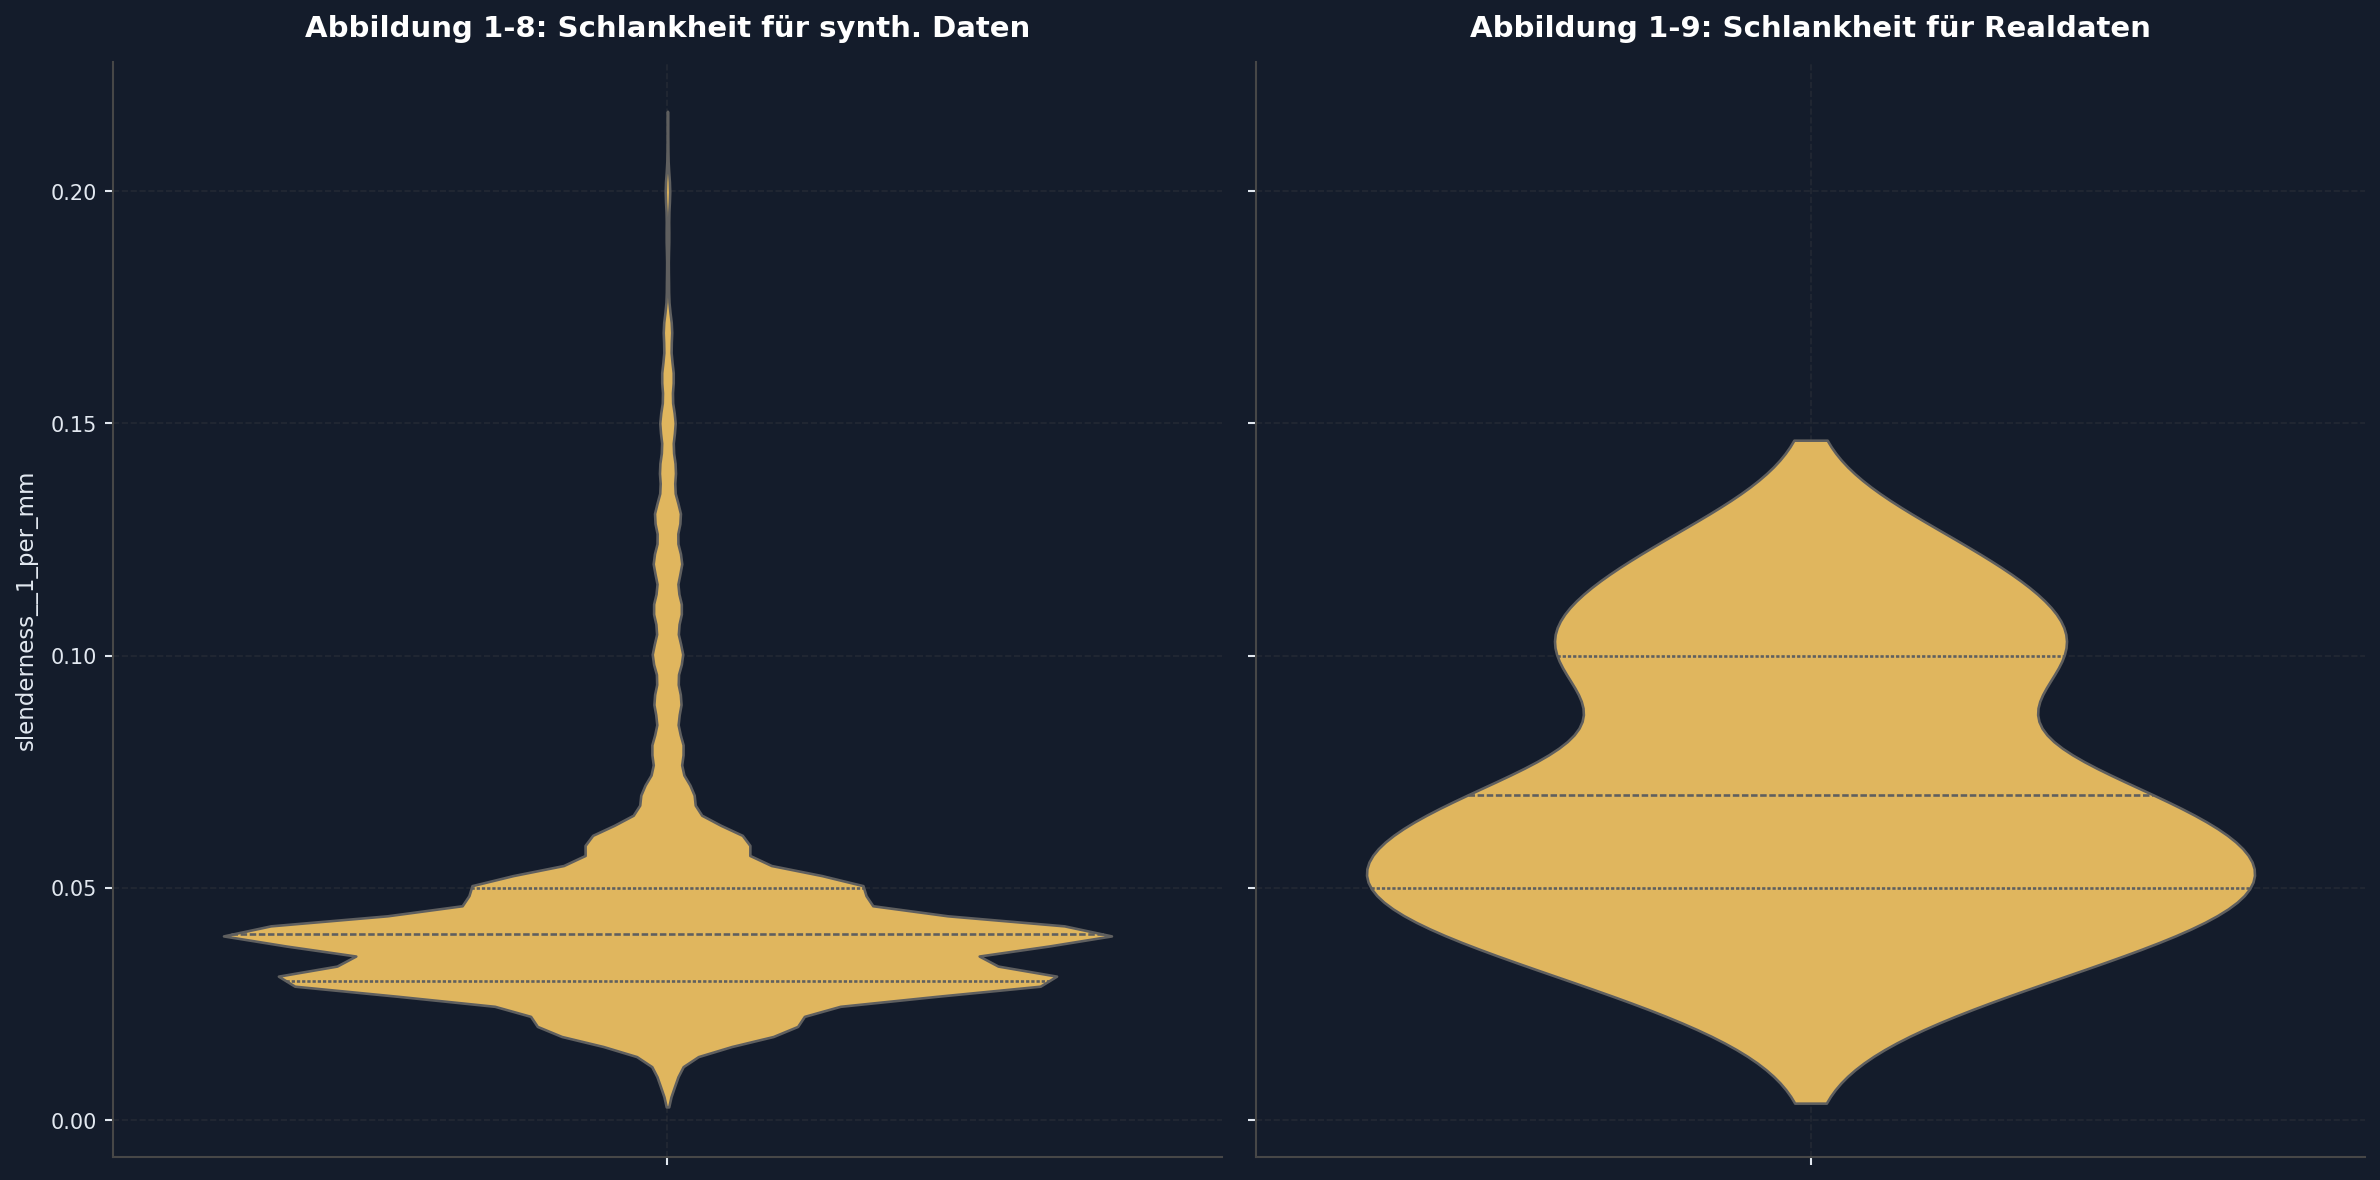

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, sharey="row", figsize=(16, 8))

# synth. Daten
sns.violinplot(
    y=df_scatter_s["slenderness__1_per_mm"],
    inner="quart", ax=ax1,
    color=mpl_theme.primary_color,
)
ax1.set_title("Abbildung 1-8: Schlankheit für synth. Daten")
ax1.grid(True, alpha=0.3)

# zum Vergleich Realdaten
sns.violinplot(
    y=df_scatter["slenderness__1_per_mm"],
    inner="quart", ax=ax2,
    color=mpl_theme.primary_color,
)
ax2.set_title("Abbildung 1-9: Schlankheit für Realdaten")
ax2.grid(True, alpha=0.3)

plt.show()

**Violinplot für die Schlankheit**:  
- Zur Verdeutlichung der dichten Verteilung der synthehtischen Daten bei gedrungenen Balken (geringe Schlankheit), wurde ein extra Violinplot hinzugefügt und der der Realdaten zum Vergleich daneben gelegt.

#### Violinplots mit z-Score für synth. Daten

In [67]:
from outsourced import plot_radial_zscore

om = plot_radial_zscore(
    df=df_synth,
    title="Abbildung 1-10: Outlier-Analyse mit Z-Score (synth. Daten)",
    label_col= "", #"beam_number",
    theme=mpl_theme,
    use_curved_text=True,
    text_scale=0.07,
    use_text_offset=True,
)
p = sum(om) / len(om) * 100
print(f"Anteil pot. Ausreißer {p:.2f}%")

Anteil pot. Ausreißer 14.09%


**Barplots**:  
- Man erkennt gut die ungleichmäßige Verteilung einiger Parameter, ebenso wie das vorhandensein von potentiellen Ausreißern.

#### Korrelations-Heatmap für synth. Daten

In [68]:
from outsourced import plot_heatmap

plot_heatmap(
    df_synth.select_dtypes(include="number"),
    title="Abbildung 1-11: Korrelationsmatrix für synth. Daten",
    theme=mpl_theme,
    palette=mpl_palette
)

**Heatmap für Korrelation**:  
- Auch in den synthetischen Daten sieht man einige Korrelationen, die nicht physikalisch bedingt sind (bspw. `concrete_cover__mm` und `insulation_depth__mm` oder `beam_length__mm` und `concrete_area__mm2`). Das heißt, es wurde bei der Parametervariation kein Grid-Search oder ähnliches angewandt, um die Parameter unabhängig voneinander zu variieren. Stattdessen wurde ein Bias eingebracht, indem die Parameter vermutlich so variiert wurden, dass sie gewissen Plausibilitätskriterien oder Bemessungsnormen entsprechen.

#### t-SNE für synth. Daten

In [99]:
from outsourced import specific_tsne_plot

embedding_synth = specific_tsne_plot(
    df=df_synth,
    title="t-SNE Visualisierung für synth. Daten",
    fig_pre="Abbildung 1-12.",
    theme=mpl_theme,
    do_plot=True,
    palette="flare",
    edgecolor=mpl_theme.secondary_color,
)

**t-SNE-Plot**:  
- Aus dem t-SNE-Plot lassen sich einige Identitäten anhand der Clusterbildung erkennen.
- Es bilden sich zwei sehr große Gruppen, oben und unten, mittig in den Plots (oben hohe FRP-Festigkeit, unten niedrige).
- Beide großen Gruppen weisen eine schmale veritkale Trennlinie auf, wodurch sie sich in Teilgruppen links und rechts der Trennlinie aufteilen lassen. Links sind hauptsächlich Balken mit Länge kleinergleich 3m und rechts Balken mit Länge größergleich 3m. Die Trennlinie entsteht vermutlich aufgrund der nicht untersuchten Balken mit Längen um die 3m, siehe auch den Scatterplot in Abbildung 1-7.1.
- Die Anhäufung der Kreise rechts oben deutet auf eine hohe Ähnlichkeit der Beobachtungen hin, bei denen FRP angesetz wurde und das Abbruchkriterium das "Brandende" ist. Die Anhäufung lässt sich in eine linke obere Teilgruppe mit niedriger FRP-Festigkeit teilen, wobei die andere Teilgruppe rechts höhere FRP-Festigkeiten aufweist.
- Eine weitere klare Gruppe bildet sich links unten mit den X'en. Hierbei handelt es sich um Balken ohne FRP, die versagt haben.
- Im Mittelbereich steigt die Betonfläche von links nach rechts an, ebenso wie die Bewehrungsfläche. Die Schlankheit wird von links nach rechts schnell geringer. Auch hier erkennt man die Masse an gedrungenen Balken.
- Die anderen kleineren Cluster (links an der oberen Hauptgruppe, plus zwei links unterhalb der unteren Hauptgruppe) zeichnen sich durch fehlende Dämmung aus.

#### Identifizieren von Clustern mit HDBSCAN

In [70]:
from outsourced import cluster_analysis_plot

# Cluster mit HDBSCAN ermitteln
df_summary_synth = cluster_analysis_plot(
    df_synth,
    embedding_synth,
    title="Abbildung 1-13: Gruppenbildung mit t-SNE + HDBSCAN (synth. Daten)",
    theme=mpl_theme,
)

c:\Users\benep\Documents\PythonProjects\IHK DataScientist\Woche 09-10 Abschlussprojekt\Abschluss Github\outsourced.py:2068: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



##### Tabelle 7: Hauptmerkmale der synthetischen Daten

In [71]:
df_summary_synth

,cluster,Anzahl_Punkte,Anteil_Prozent,Verteilung (is_real),Hauptmerkmale
0,0,264,1.2,-,"transition_temp_glass__deg ↓, insulation_thickness__mm ↓, insulation_specific_heat_cap__J_per_degmm3 ↓, insulation_thermal_conductivity__W_per_mmdeg ↓, frp_youngs_modulus__MPa ↓"
1,1,287,1.3,-,"insulation_depth__mm ↑, concrete_cover__mm ↑, steel_area__mm2 ↑, initial_capacity__kNm ↑, load_ratio__percent ↓"
2,2,194,0.9,-,"frp_tens_strength__MPa ↑, frp_youngs_modulus__MPa ↑, insulation_depth__mm ↑, concrete_cover__mm ↑, steel_area__mm2 ↑"
3,3,13033,60.9,-,"frp_tens_strength__MPa ↓, frp_youngs_modulus__MPa ↓, frp_area__mm2 ↑, transition_temp_glass__deg ↑, insulation_thickness__mm ↑"
4,4,6726,31.5,-,"frp_tens_strength__MPa ↑, frp_youngs_modulus__MPa ↑, frp_area__mm2 ↓, transition_temp_glass__deg ↓, load_ratio__percent ↑"
5,5,810,3.8,-,"insulation_thickness__mm ↓, insulation_specific_heat_cap__J_per_degmm3 ↓, insulation_thermal_conductivity__W_per_mmdeg ↓, insulation_depth__mm ↓, frp_tens_strength__MPa ↓"
6,6,70,0.3,-,"insulation_thickness__mm ↓, insulation_specific_heat_cap__J_per_degmm3 ↓, insulation_thermal_conductivity__W_per_mmdeg ↓, concrete_area__mm2 ↓, concrete_cover__mm ↓"


**Beschreibung der Cluster (synth. Daten)**:  

Zur Auswahl der Hauptmerkmale werden die größten fünf Absolutwerte der Z-Scores der Feature-Mittelwerte betrachtet  
$$max \left(\ \left|\frac{\mu_{feature} - \mu_{global}}{\sigma_{global}}\right|\ \right)$$

- Gruppe 0:
    - Wird maßgeblich von der Glasübergangstemperatur bestimmt sowie von der Dämmung
    - Betrachtet man die t-SNE Plots, sieht man, dass es sich bei dieser Gruppe um Balken ohne Verstärkung und ohne Dämmung handelt
- Gruppe 1 & 2:
    - Bei Gruppen 1 und 2 handelt es sich um die tragfähigsten Balken mit Simulationsende bei 300 Minuten (ohne Versagen)
    - Gruppe 1 wird maßgeblich von den Eigenschaften der Dämmung und des bewehrten Betons beeinflusst (hohe Dicke der Dämmung, große Betondeckung, große Bewehrungsmenge)
    - Gruppe 2 zeichnet sich durch hochfestem FRP aber geringer Menge FRP aus
- Gruppe 3:
    - Größte Gruppe mit knapp 61% der Daten
    - Hauptmerkmale haben alle etwas mit dem FRP zu tun sowie Dicke der Dämmung
    - Es handelt sich um vergleichsweise geringwertiges FRP hinsichtlich Festigkeit und E-Modul, aber größerer FRP-Fläche
- Gruppe 4:
    - Zweitgrößte Gruppe mit knapp 32% der Daten
    - Es handelt sich um den Gegenpart zu Gruppe 4, da Gruppe 5 vergleichsweise hochwertiges FRP aber mit geringer Fläche hat
- Gruppe 5:
    - wird maßgeblich von der Dämmung beeinflusst sowie der Zugfestigkeit von FRP
    - Mit den t-SNE Plots zeigt sich, dass hier ungedämmte Balken vorliegen, die aber mit FRP verstärkt sind
- Gruppe 6:
    - eine kleine Abspaltung von Gruppe 5, die sich durch eine geringe QS-Fläche und wenig Betondeckung unterscheidet

#### Resultat der EDA für die synthetischen Daten

**Simulation / Model Bias**:  
- Entsteht durch die Annahmen / Vereinfachungen für das numerische Modell mit Finite-Elemente-Methode
=> Bildet das FE-Modell die Realität nicht hinreichend ab, so wird die Vorhersage realer Balken entsprechend beeinflusst

**Zwischenfazit**:  
- Da die Anzahl der synthetischen Daten groß ist und die Realdaten bei Weitem übersteigt, wird die Physik anhand der synthetischen Daten gelernt werden. Das heißt das ML-Modell wird sehr stark einen Bias aus den Simulationsannahmen und der Wahl der Parameter enthalten.
- Da zum großen Teil gedrungene Bauteile (geringe Schlankheit) simuliert wurden, wird das ML-Modell schlechter bzw. mit größerer Unsicherheit bei schlanken Bauteilen performen. Gerade die sind es jedoch, die das größere wirtschaftliche Potential bergen.
- Die Häufung der simulierten Versagensfälle um die 50 Minuten heißt im Hinblick auf die Realdaten, dass hier viele Versagensfälle synthetischer Daten zusammenfallen mit planmäßig beendeten Laborversuchen (siehe Abb. 1-1.19 und Abb. 1-6.19). Durch die Rechtszensur wird hier ein schlechteres Ergebnis erzielt als bei tatsächlichen Versagensfällen, da lediglich die Information vorliegt, dass der betrachtete Probekörper mindestens die Zeit X gehalten hat.
- Durch die Multikolliniearität wird es für ein ML-Modell schwieriger zu unterscheiden, welche Parameter wirklich Einfluss auf die Zielvariable haben.
- Die mit der Parametererzeugung angelegten "logischen" Kombinationen lernt das Modell bspw., dass *großer Balken*, *viel Stahl* und *Feuerwiderstand* gleichgesetzt werden können. Für untypische Bauteile die abweichende Parametervariationen aufweisen, muss das Modell extrapolieren. Aufgrund des Bias wird es hier aber eher schlechte Vorhersagen treffen.
- Aufgrund der Daten-Lücke zwischen 2,8 m und 3,4 m kann nur schwerlich ein Overfitting auf die Realdaten in diesem Bereich ausgeschlossen werden.

## 2. Preprocessing

### Data Cleaning

**Allgemein**:  
- Für die Zusammenführung mit den synthetischen Daten werden die Einheiten alle in SI-Einheiten umgerechnet (m, kg, s, K), wobei die Zielvariable `fire_resistance__min` in Minuten bleibt, damit die Vorhersage auch direkt in Minuten vorliegt.

**Realdaten**:  
Die Ausreißer lassen sich besonders gut im Box-Plot (Abb. 1-4) erkennen. Sie ergeben sich als:
- **B30**, **B31**: Größere Bewehrungsfläche als die anderen => **ohne Handlungsbedarf**
- **B11**, **B45**, **B46**, **B47**: große Werte für FRP-Fläche, nach KI-Recherche aber wohl so angedacht => **ohne Handlungsbedarf**
- **B8**: sehr geringer Stahl E-Modul => **mal 1000** (Umrechnung GPa in MPa) => gleiche Größenordnung wie andere Beobachtungen
- **B11**: sehr großer Wert für FRP E-Moudl => **geteilt durch 10** => gleiche Größenordnung wie andere Beobachtungen
- **B1**, **B2**, **B10**, **B12**, **B18**, **B32**, **B34**: geringe Glasübergangstemperatur => ist 0 als Anzeiger, dass kein FRP => **ohne Handlungsbedarf**
- **B38**, **B39**, **B40**: sehr hohe Werte für die thermischen Eigenschaften der Dämmung => **geteilt durch 10** => gleiche Größenordnung wie andere Beobachtungen
- **B32 - B43**: sehr geringe Werte für die Lastverhältnisse => **mal 100** (Umrechnung in Prozent) => gleiche Größenordnung wie andere Beobachtungen
- Spalte `deflection_at_failure__mm` wird gelöscht, da es eine alternative Zielvariable ist und keinen Eingangsparameter darstellt
- **B16**, **B17**: sind in den Scatterplots aufgefallen als zwei Punkte mit hoher Feuerwiderstandsdauer, jedoch schwachen geometrieschen Parametern (Betonfläche, Betondeckung, Bewehrungsfläche, etc.). Im Vergleich zu ähnlichen Konfigurationen erreichen B16 und B17 doppelt so hohe Feuerwiderstandsdauern => **löschen**
- Alle Beobachtungen kleiner(gleich) 50 Minuten werden entfernt. Hier wurden alle Versuche planmäßig beendet und liefern somit aufgrund der Rechtszensur keine Information zur erreichbaren Feuerwiderstandsdauer und verzerren die Vorhersagen in diesem Bereich.

**Synthetische Daten**:
- Die zusätzlichen Spalten, die nicht bei den Realdaten vorkommen, werden gelöscht (`limit_state`, `initial_capacity__kNm`, `final_capacity__kNm`).
- Die Spalte `deflection_at_failure__mm` wird wie bei den Realdaten gelöscht, da sie eine alternative Zielvariable ist und keinen Eingangsparameter darstellt.
- Der Parameter `insulation_thermal_conductivity__W_per_mmdeg` hat zwar eine andere Einheit angegeben, bei Betrachtung der Daten fällt aber auf (Vergleich max, min, etc.), dass vermutlich nur der Spaltenkopf anders benannt wurde, die Daten aber wie bei den Realdaten in $\frac{W}{m \cdot K}$ vorliegen => **nur umbenennen**
- Die Daten mit vorzeitigem Simulationsende bei 300 Minuten werden allesamt entfernt, da hier kein Informationsgewinn vorliegt. Die Maximaldauer bei den Realdaten, bei den ein Versagen eintrat, liegt nur bei etwa 200 Minuten.

In [72]:
# DATEN LÖSCHEN

# Realdaten
df_real_cleaned = df_real.copy()
#   B16, B17 als Ausreißer (besser wäre anahnd der Parametergrenzen zu löschen)
df_real_cleaned = df_real_cleaned[
    (df_real_cleaned["beam_number"] != "B16")
    & (df_real_cleaned["beam_number"] != "B17")
]
#   rechtszensierte Daten mit Feuerwiderstandsdauer kleiner(gleich) 50 Minuten rausfiltern
df_real_cleaned = df_real_cleaned[
    (df_real_cleaned["test_end_criterion"] == 0)
    | (df_real_cleaned["fire_resistance__min"] > 50)
]
#   Spalten entfernen
df_real_cleaned = df_real_cleaned.drop(columns=["deflection_at_failure__mm"])

# Synth. Daten
df_synth_cleaned = df_synth.copy()
#   alle rechtszensierten Daten rausfiltern
df_synth_cleaned = df_synth_cleaned[df_synth_cleaned["test_end_criterion"] == 0]
#   (zusätzliche) Spalten entfernen
df_synth_cleaned = df_synth_cleaned.drop(
    columns=[
        "limit_state",
        "initial_capacity__kNm",
        "final_capacity__kNm",
        "deflection_at_failure__mm",
    ]
)

In [73]:
# AUSREISSER BEHANDELN

# Geringer E-Modul bei B8
mask_1 = df_real_cleaned["beam_number"] == "B8"
df_real_cleaned.loc[mask_1, "steel_youngs_modulus__MPa"] *= 1000

# Hoher Wert für FRP E-Modul bei B11
mask_2 = df_real_cleaned["beam_number"] == "B11"
df_real_cleaned.loc[mask_2, "frp_youngs_modulus__MPa"] /= 10

# hohe thermische Eigenschaften bei B38, B39 und B40
mask_3 = df_real_cleaned["beam_number"].isin(["B38", "B39", "B40"])
df_real_cleaned.loc[mask_3, "insulation_thermal_conductivity__W_per_mK"] /= 10
df_real_cleaned.loc[mask_3, "insulation_specific_heat_cap__J_per_degm3"] /= 10

# geringe Lastverhältnisse bei B32 bis B43
mask_4 = df_real_cleaned["beam_number"].isin([f"B{x}" for x in range(32, 44)])
df_real_cleaned.loc[mask_4, "load_ratio__percent"] *= 100


In [74]:
# EINHEITEN ANPASSEN

from outsourced import change_units
# Einheiten anpassen und Spalten umbenennen (inplace)
change_units(df_real_cleaned)
change_units(df_synth_cleaned)

In [75]:
# Ausgabe Anzahl Beobachtungen vs Parameter
print("shape real_cleaned: ", df_real_cleaned.shape)
print("shape synth_cleaned: ", df_synth_cleaned.shape)

shape real_cleaned:  (42, 20)
shape synth_cleaned:  (20903, 20)


### Feature Engineering

Aus den gegebenen Parametern lassen sich physikalische Parameter ableiten, die größeren Einfluss auf das Versagen haben:  
- Aus der Betonfläche, dem Paper [1] und üblichen Seitenverhältnissen von Rechteckquerschnitten lassen sich die **Breite** und **Höhe** der Querschnitte rekonstruieren (⚠️ möglicher Bias durch falsche Annahmen)
- Mit Höhe und Breite lassen sich physikalisch aussagekräftigere Parameter berechnen, wie bspw. das **Widerstandsmoment** $W = \frac{b \cdot h^2}{6}$
- Aus der Höhe des Querschnitts wie aus aus der seitlichen Höhe der Dämmung und der Breite lässt sich ein **Profilfaktor** berechnen (exponierter Umfang durch Fläche)
- Mit den Abmessungen und der aufgebrachten Gesamtlast lässt sich weiterhin eine Art **Ersatzspannung** berechnen
- Die **Biegeschlankheit** kann mit der Balkenlänge und der Höhe berechnet werden
- Aus Betonfläche und Bewehrungsfläche lässt sich der **Bewehrungsgrad** ermitteln
- Aus der Bewehrungsfläche und der Betondeckung wird der **Achsabstand der Bewehrung** ermittelt
- Mit der Dicke der Dämmung und der Wärmeleitfähigkeit ergibt sich der **Wärmedurchlasswiderstand**
- Spezifische Wärmekapazität und Wärmeleitfähigkeit lassen sich als **Temperaturleitfähigkeit** zusammenfassen

In [76]:
# Zusammenführen der Datensätze mit Label `is_real` zum Unterscheiden der Datensätze
df_real_cleaned["is_real"] = 1
df_synth_cleaned["is_real"] = 0
df_baseline_pre = pd.concat([df_synth_cleaned, df_real_cleaned], ignore_index=True)

In [77]:
from outsourced import engineer_new_params
# Neue Parameter anlegen (inplace)
df_feats = df_baseline_pre.copy()
engineer_new_params(df_feats)


Folgende neue Parameter wurden neu angelegt:
--------------------------------------------
width__m, height__m, section_modulus__m3, stress_proxy__Pa, 
section_factor__1_per_m, slenderness__1_per_m, reinforcement_ratio, 
ax_dist__m, thermal_resistance__m2K_per_W, thermal_diffusivity__m2_per_s



### Feature Reduction

Durch die zuvor neu eingebrachten Parameter sind folgende redundant:  
- Balkenlänge: `beam_length__m`
- Betonfläche: `concrete_area__m2`
- Betondeckung: `concrete_cover__m`
- Stahlfläche: `steel_area__m2`
- Dicke der Dämmung: `insulation_thickness__m`
- Höhe der seitl. Dämmung: `insulation_depth__m`
- Spez. Wärmekapazität: `insulation_specific_heat_cap__J_per_Km3`
- Wärmeleitfähigkeit: `insulation_thermal_conductivity__W_per_mK`
- Gesamtbelastung: `total_load__N`
- Höhe: `height__m`
- Breite: `width__m`

Weiterhin wird folgenden Parametern ein geringer Einfluss unterstellt:  
- `concrete_compr_strength__Pa`: die Betondruckfestigkeit, da das Versagen maßgeblich von den Zugfestigkeiten beeinflusst wird, Beton aber verhältnismäßig geringe hat und die Versuche weiterhin vermutlich nicht darauf konfiguriert sind, um ein Druckversagen zu erzeugen (andere Annahmen müssten durch Literaturrecherche geklärt werden, bspw. Einfluss auf Abplatzungen)
- `steel_youngs_modulus__Pa`: der E-Modul der Bewehrung, da durch das temperaturbedingte Weicherwerden des Stahls sich Einflüsse auf die Verformung ergeben, aber hier wird das FRP maßgebender sein
- `frp_tens_strength__Pa`: auch hier wird der E-Modul maßgebender sein, außerdem ist in den Realdaten hier eine negative Korrelation mit der Feuerwiderstandsdauer und in den synthetischen Daten ist eine Korrelation von fast 1 mit dem E-Modul von FRP
---
*Die Benennung der Parameter richtet sich bereits nach den neuen Namen nach dem Data Cleaning und Feature Engineering*

In [78]:
# Genannte Features droppen
df_final_pre = df_feats.drop(columns=[
    "beam_length__m", "concrete_area__m2", "concrete_cover__m", "steel_area__m2",
    "insulation_thickness__m", "insulation_depth__m", "insulation_specific_heat_cap__J_per_Km3",
    "insulation_thermal_conductivity__W_per_mK", "total_load__N", "height__m", "width__m",
    "concrete_compr_strength__Pa", "steel_youngs_modulus__Pa", "frp_tens_strength__Pa"
    ])

print("shape df_final_pre:", df_final_pre.shape)

shape df_final_pre: (20945, 17)


In [79]:
print("\nFolgende Parameter existieren nun:")
print("  ","\n   ".join(df_final_pre.columns.tolist()))


Folgende Parameter existieren nun:
   beam_number
   frp_area__m2
   steel_yield_strength__Pa
   frp_youngs_modulus__Pa
   transition_temp_glass__K
   load_ratio__percent
   test_end_criterion
   fire_resistance__min
   is_real
   section_modulus__m3
   stress_proxy__Pa
   section_factor__1_per_m
   slenderness__1_per_m
   reinforcement_ratio
   ax_dist__m
   thermal_resistance__m2K_per_W
   thermal_diffusivity__m2_per_s


In [80]:
# Features die in den Trials von Optuna definitiv mit dabei sein sollen
MUST_HAVE_FEATS = [
    "load_ratio__percent",
    "stress_proxy__Pa",
    "ax_dist__m",
    "reinforcement_ratio",
    "section_modulus__m3",
    "thermal_resistance__m2K_per_W",
]

### Visualisierungen

#### t-SNE und HDBSCAN

In [81]:
from outsourced import specific_tsne_plot

embedding_feats = specific_tsne_plot(
    df=df_feats,
    title="Abb. 2-1.x: t-SNE Visualisierung für Daten nach FE",
    fig_pre="Abbildung 2-1.",
    theme=mpl_theme,
    do_plot=False,
    edgecolor=mpl_theme.secondary_color
)

In [82]:
from outsourced import cluster_analysis_plot

df_summary_feats = cluster_analysis_plot(
    df_feats,
    embedding_feats,
    min_cluster_size=5,
    title="Abbildung 2-2: HDBSCAN-Gruppen nach Feature Engineering",
    theme=mpl_theme,
    hue="cluster",
    style="is_real",
    markers={0: "o", 1: "X"}
)

#### Tabelle 8: Hauptmerkmale nach Feature Engineering und Clustering mit HDBSCAN 

In [83]:
df_summary_feats

,cluster,Anzahl_Punkte,Anteil_Prozent,Verteilung (is_real),Hauptmerkmale
0,-1,43,0.2,"0=30, 1=13",potentiell Rauschen / Ausreißer
1,0,267,1.3,"0=264, 1=3","transition_temp_glass__K ↓, insulation_thickness__m ↓, insulation_specific_heat_cap__J_per_Km3 ↓, insulation_thermal_conductivity__W_per_mK ↓, frp_youngs_modulus__Pa ↓"
2,1,1320,6.3,0=1320,"insulation_thickness__m ↓, insulation_specific_heat_cap__J_per_Km3 ↓, insulation_thermal_conductivity__W_per_mK ↓, thermal_resistance__m2K_per_W ↓, thermal_diffusivity__m2_per_s ↓"
3,2,13035,62.2,"0=13033, 1=2","frp_tens_strength__Pa ↓, frp_youngs_modulus__Pa ↓, frp_area__m2 ↑, transition_temp_glass__K ↑, insulation_thickness__m ↑"
4,3,23,0.1,1=23,"is_real ↑, steel_yield_strength__Pa ↑, transition_temp_glass__K ↓, stress_proxy__Pa ↑, concrete_compr_strength__Pa ↑"
5,4,3197,15.3,"0=3196, 1=1","frp_tens_strength__Pa ↑, frp_youngs_modulus__Pa ↑, beam_length__m ↓, frp_area__m2 ↓, section_modulus__m3 ↓"
6,5,2675,12.8,0=2675,"frp_tens_strength__Pa ↑, frp_youngs_modulus__Pa ↑, beam_length__m ↑, height__m ↑, concrete_area__m2 ↑"
7,6,385,1.8,0=385,"steel_area__m2 ↑, section_modulus__m3 ↑, reinforcement_ratio ↑, frp_tens_strength__Pa ↑, frp_youngs_modulus__Pa ↑"


**Beschreibung der Cluster (finaler Datensatz)**:  

Zur Auswahl der Hauptmerkmale werden die größten fünf Absolutwerte der Z-Scores der Feature-Mittelwerte betrachtet  
$$max \left(\ \left|\frac{\mu_{feature} - \mu_{global}}{\sigma_{global}}\right|\ \right)$$

___Interpretation___  

Als erstes fällt auf, dass sich nicht mehr oder weniger Gruppen gebildet haben, obwohl extensives Feature-Engineering betrieben wurde, eine synth. Gruppe vollständig gelöscht wurde (Daten mit Abbruchkriterium Simulations- bzw. Brandende) und die Realdaten zum synthetischen Datensatz hinzugefügt wurden. Das kann einerseits sein, da die gelöschte Gruppe mit einer "Realgruppe" aufgefüllt wurde. Andererseits lässt sich daraus ableiten, dass die synthetischen Daten strukturell dominieren und Archetypen (bspw. niedrige/hohe FRP-Festigkeit) bestehen bleiben. Dass sich die Struktur aber kaum geändert hat, heißt, dass die Löschung der synthetischen Daten mit Brand- bzw. Simulationsende (300 min FWD) absolut sauber war und keine anderen Daten dadurch beeinflusst wurden.  

Anhand der Tabelle 8 erkennt man, dass die Gruppe 3 eindeutig allein dem Realdatensatz zuzuweisen ist (`is_real == 1`). Gruppe 3 macht anteilig ca. 50% des Realdatensatzes aus, was heißt, dass keine synthetischen Daten erzeugt wurden, die nahe dieser Gruppe liegen. Noch kritischer ist der Aspekt, dass 13 weitere Punkte, die allesamt aus den Realdaten stammen, potentiell als Rauschen bzw. Ausreißer gelten, da sie keiner anderen Gruppe zugeordnet wurden. Lediglich die verbleibenden 6 Beobachtungen wurden in andere synthetisch dominierte Gruppen eingeteilt. Das heißt etwa 85% der Realdaten liegen völlig außerhalb der von den synthetischen Daten aufgespannten Parameterverteilung.


In [84]:
from outsourced import specific_tsne_plot

embedding_final = specific_tsne_plot(
    df=df_final_pre,
    title="t-SNE Visualisierung für Daten nach FE+FR",
    fig_pre="Abbildung 2-3.",
    theme=mpl_theme,
    do_plot=False,
    edgecolor=mpl_theme.secondary_color
)

In [85]:
from outsourced import cluster_analysis_plot

df_summary_final = cluster_analysis_plot(
    df_final_pre,
    embedding_final,
    min_cluster_size=5,
    title="Abbildung 2-4: HDBSCAN-Gruppen nach Feature Engineering und Feature Reduction",
    theme=mpl_theme,
    palette=mpl_palette,
    hue="cluster",
    style="is_real",
    markers={0: "o", 1: "X"}
)


#### Tabelle 9: Hauptmerkmale nach Feature Engineering und Feature Reduction

In [86]:
df_summary_final

,cluster,Anzahl_Punkte,Anteil_Prozent,Verteilung (is_real),Hauptmerkmale
0,-1,4081,19.5,"0=4069, 1=12",potentiell Rauschen / Ausreißer
1,0,267,1.3,"0=264, 1=3","transition_temp_glass__K ↓, frp_youngs_modulus__Pa ↓, thermal_resistance__m2K_per_W ↓, section_factor__1_per_m ↑, thermal_diffusivity__m2_per_s ↓"
2,1,23,0.1,1=23,"is_real ↑, steel_yield_strength__Pa ↑, transition_temp_glass__K ↓, stress_proxy__Pa ↑, reinforcement_ratio ↑"
3,2,637,3.0,0=637,"thermal_diffusivity__m2_per_s ↑, frp_youngs_modulus__Pa ↑, section_modulus__m3 ↑, thermal_resistance__m2K_per_W ↓, frp_area__m2 ↓"
4,3,1312,6.3,0=1312,"thermal_diffusivity__m2_per_s ↑, frp_area__m2 ↑, section_modulus__m3 ↑, thermal_resistance__m2K_per_W ↓, frp_youngs_modulus__Pa ↓"
...,...,...,...,...,...
154,153,13,0.1,0=13,"load_ratio__percent ↓, section_modulus__m3 ↓, steel_yield_strength__Pa ↑, slenderness__1_per_m ↓, frp_youngs_modulus__Pa ↓"
155,154,29,0.1,0=29,"steel_yield_strength__Pa ↓, reinforcement_ratio ↓, ax_dist__m ↑, load_ratio__percent ↑, slenderness__1_per_m ↑"
156,155,42,0.2,0=42,"ax_dist__m ↑, reinforcement_ratio ↓, stress_proxy__Pa ↓, slenderness__1_per_m ↑, frp_youngs_modulus__Pa ↓"
157,156,19,0.1,0=19,"ax_dist__m ↑, reinforcement_ratio ↓, stress_proxy__Pa ↓, steel_yield_strength__Pa ↓, frp_youngs_modulus__Pa ↓"


- Durch Feature Reduction bleiben die Gruppe der Realdaten immer noch unberührt, obwohl die vorigen Cluster noch feiner unterteilt wurden.
- Auch die Zahl der Real-Ausreißer hat sich kaum geändert.
- Durch das Feature Engineering mit Feature Reduction wurden vermutlich die Parameter derart diskretisiert, dass die ebenfalls diskreten Strukturen in den synthetischen Daten offengelegt werden.
- Die Features, die zuvor glättend gewirkt haben, sind nach Feautre Reduction nicht mehr vorhanden.
- Feature Reduction hat aber die versteckten Grüppchen vorzeitig aufgedeckt, die XGBoost einfach in tieferen Ebenen selbst entdeckt hätte, man davon aber wenig mitbekommen hätte.
- TODO: Testen, ob Basis-Parameter wie bspw. Breite dem Modell etwas helfen.


Auswirkungen aufs Machine Learning:
- Durch die vielen kleinen Grüppchen besteht Gefahr für Overfitting (auch wenn diese nicht direkt sichtbar sind, wie bspw. vor Feature Reduction aber nach Feature Engineering)
- Gefahr, dass Bias sich ins Modell "brennt" (durch mit Bias behaftete Features, die in Grüppchenbildung resultieren)


Fazit für die Datengenerierung:
- Bei der Datengenerierung sollte bspw. LHS (Latin Hypercube Sampling) angewandt werden, statt der rasterartig verteilten Parameter.
- Alternative: Evtl. leichtes Rauschen in die synthetischen Daten einbringen, physikalische Sinnhaftigkeit sollte aber beachtet werden.

#### Heatmap

In [87]:
from outsourced import plot_heatmap

plot_heatmap(
    df_final_pre.select_dtypes(include="number"),
    title="Abbildung 2-5: Korrelationsmatrix für finale Daten",
    theme=mpl_theme,
    palette=mpl_palette
)

## 3. ML-Modell Training

### Train-Test-Split

#### Wahl der Trainings- und Testdaten

Um ein robustes Modell zu entwickeln, das nicht nur mathematische Formeln reproduziert, sondern die physikalische Realität von Brandversuchen widerspiegelt, wird beim Datensplit der Ansatz "Train on Physics, Test on Reality" verfolgt:  

**Der physikalische Anker:** Die synthetischen Daten bilden mit über 20.000 Beobachtungen das Rückgrat des Trainings, um dem Modell die grundlegenden physikalischen Gesetzmäßigkeiten und Trends beizubringen (mit entsprechenden Simulation Bias).  

**Der Realitätscheck:** Da die Realdaten die labortechnische Komplexität enthalten, fungieren sie als Testinstanz.  

**Selektives Test-Set:** Im Test-Set landen daher ausschließlich Realdaten, bei denen ein tatsächliches Versagen dokumentiert wurde (`test_end_criterion` == 0). Dies verhindert, dass die Evaluierung durch rechtszensierte Daten (Versuchsabbruch ohne Versagen) verfälscht wird.  

**Umgang mit Zensierung:** Beobachtungen der Laborversuche, bei denen ein Balken das Ende des Brandversuchs ohne Versagen erreichte, verbleiben im Trainingsset. Sie dienen dort als Grenzwerte, um dem Modell beizubringen, welche Belastungsszenarien sicher gehalten werden.  

#### Gewichtung der Daten (Sample Weights)

Die signifikante Diskrepanz im Probenumfang zwischen den synthetischen Daten (~20.000 Beobachtungen) und den verfügbaren Realdaten (50 Beobachtungen) erfordert eine gezielte Steuerung der Verlustfunktion über Sample Weights:  

**Kompensation des Daten-Ungleichgewichts:** Ohne Gewichtung würde der Trainingsalgorithmus die wenigen Realdaten als statistisches Rauschen behandeln, da die Minimierung des Gesamtfehlers primär durch die schiere Masse der synthetischen Proben bestimmt würde.  

**Stärkung des "Realitätssignals":** Durch den dynamisch zugewiesenen Gewichtungsfaktor erhalten die experimentellen Versuche ein höheres "Stimmrecht". Dies zwingt das Modell dazu, die physikalischen Abweichungen der Realität stärker zu berücksichtigen als die idealisierten numerischen Annahmen aus dem synthetischen Datensatz.  

**Berücksichtigung der Datenqualität:** Da Realdaten ohne Versagen (`test_end_criterion` == 1) lediglich eine Mindesthaltbarkeit garantieren, erhalten sie ein geringeres Gewicht als Datenpunkte mit dokumentiertem Versagen. Dies verhindert, dass das Modell lernt, die Feuerwiderstandsdauer auf den Zeitpunkt eines "willkürlichen" Versuchsabbruchs zu optimieren.  

Die Gewichtung erfolgt dynamisch mit Optuna. Die Gewichtungsfunktion sieht dabei 3 Gewichte vor:
- **weight_real**: Gewichte für Realdaten (Optimierungsbereich 1.0 bis 20.0)
- **weight_failure**: Gewichte für alle Daten (real + synth.) bei Versagen (Optimierungsbereich 1.0 bis 10.0)
- **weight_censored**: Gewicht für alle Daten (real + synth.) bei Rechtszensur (Optimierungsbereich 0.01 bis 1.1)

Das heißt die Gewichtung der Realdaten kann einen maximalen Wertebereich von 1.0 bis 200.0 aufspannen.

#### Custom Scorer

Als Scorer wird eine eigene Funktion definiert, um die Rechtszensur zu behandeln. Die Zielvariable wird markiert, indem die rechtszensierten Daten ein negatives Vorzeichen bekommen. Im Scorer wird nach den negativen Werten gefiltert, wonach diese dann nicht bestraft werden, wenn das Modell einen höheren Wert vorhersagt als tatsächlich vorliegt. Wenn der tatsächliche Wert also 20 Minuten beträgt, weil der Versuch schlicht nach dieser Zeit ohne ein Versagen beendet wurde, so darf das Modell ohne Bestrafung höhere Werte vorhersagen, da diese durchaus eintreten könnten.

#### Monotonic Constraints

Damit das Modell in physikalischen Grenzen lernt, werden bestimmte Abhängigkeiten vorgegeben. Dem Modell wird bspw. vorgegeben, dass ein höheres Widerstandsmoment auch in eine höhere Feuerwiderstandsdauer resultiert. Oder eine höhere Ausnutzung im Kaltfall zu einer kleineren Feuerwiderstandsdauer führt.

In diesem Fall heißt das, dass das Modell trotz der vielen kleinen Cluster sicher über die Lücken agieren kann, da es weiß, welche Tendenz der Feuerwiderstandsdauer zugrunde liegt, wenn es von einem Cluster zum nächsten geht, also wenn Parameter sich ändern.

#### Dynamische Feature Selection

Dem zu optimierenden Parameterraum wird ebenfalls hinzugefügt, ob bestimmte Parameter etwa als zweitrangig eingestuft werden. Optuna kann hier entscheiden, ob bspw. der Parameter Glasübergangstemperatur zu einem besseren Modell beiträgt. Bspw. der Parameter `transition_temp_glass__K` bekommt für die Optuna-Trials ein `use_` vorangestellt. Optuna optimiert dann, indem es `use_transition_temp_glass__K` auf Wahr oder Falsch setzt.

#### Holdout-Set

Mit dem Holdout-Set wird normalerweise die Performance des fertigen Modells getestet. Das Problem hier ist die geringe Menge an zur Verfügung stehenden unzensierten Realdaten, die nach Data Cleaning und Holdout-Set noch zur Verfügung stehen. Das Holdout-Set wird im weiteren nur als Konzept aufgeführt, hat aber aufgrund der wenigen Beobachtungen darin keine statistische Aussagekraft.

#### Eingangswerte

In [88]:
# SPALTEN FÜR TARGET UND FEATURES
target_col = "fire_resistance__min"
no_feature = [target_col, "beam_number", "test_end_criterion", "is_real"]

In [89]:
# CUSTOM CV SPLITTER
from outsourced import CustomSplitter
custom_splitter = CustomSplitter(n_splits=5)

In [90]:
# EXKLUSIVES TEST-SET
holdout_mask = (df_final_pre["test_end_criterion"] == 0) & (
    df_final_pre["is_real"] == 1
)  # Maske für Realdaten mit Versagen
holdout_index = (
    df_final_pre[holdout_mask].sample(frac=0.20, random_state=1234)
).index  # Finale Test-Set Indizes, deren Beobachtungen unberührt bleiben

# Final
df_holdout = df_final_pre.loc[holdout_index]
y_holdout = df_holdout[target_col]  # Target
X_holdout = df_holdout.drop(columns=no_feature)  # Features
df_final = df_final_pre.drop(
    holdout_index
)  # Test-Set aus df_final ausschließen

print(f"Das Holdout-Set besteht aus {len(holdout_index)} Daten")

Das Holdout-Set besteht aus 4 Daten


### XGBoost mit Optuna

#### Modell definieren und trainieren

In [91]:
from outsourced import create_objective
import optuna

# TARGET UND FEATURES
y = df_final[target_col]                # Target
X = df_final.drop(columns=no_feature)   # Features

# OBJECTIVE FÜR OPTIMIZATION
objective = create_objective(df_final, X, y, custom_splitter, MUST_HAVE_FEATS)

# STUDY SETUP
study_name = "xgboost_fire_linkedin"
storage_name = "sqlite:///optuna_database_fire.db"

sampler = optuna.samplers.TPESampler(
    # Die ersten 50 Trials sind rein zufällig im ganzen Suchraum verteilt
    n_startup_trials=50,
)

study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction="minimize",
    load_if_exists=True,
    sampler=sampler
)

# TRAIN
study.optimize(objective, show_progress_bar=True, n_trials=10, n_jobs=4)

[I 2026-03-17 16:42:50,664] Using an existing study with name 'xgboost_fire_linkedin' instead of creating a new one.


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-17 16:43:16,454] Trial 1559 finished with value: 17.595869547671498 and parameters: {'weight_real': 4.593483810408166, 'weight_failure': 1.3300549131778954, 'weight_censored': 0.8500188933523319, 'max_depth': 4, 'learning_rate': 0.02434367715163624, 'n_estimators': 785, 'reg_lambda': 17.01218261309854, 'reg_alpha': 260.5711129833294, 'colsample_bytree': 0.7916337245100392, 'subsample': 0.5785963922913134, 'use_constraints': True, 'use_frp_area__m2': True, 'use_steel_yield_strength__Pa': False, 'use_frp_youngs_modulus__Pa': False, 'use_transition_temp_glass__K': True, 'use_section_factor__1_per_m': True, 'use_slenderness__1_per_m': False, 'use_thermal_diffusivity__m2_per_s': False}. Best is trial 456 with value: 15.920211730834453.
[I 2026-03-17 16:43:16,761] Trial 1557 finished with value: 17.86929576663672 and parameters: {'weight_real': 6.185413629402553, 'weight_failure': 1.336373208151426, 'weight_censored': 0.9450315949424365, 'max_depth': 4, 'learning_rate': 0.02438745

# 4. Offen zur Interpretation

In [92]:
print(f"Train RMSE: {study.best_trial.user_attrs["train_RMSE"]:.2f} min")
print(f"Train  MAE: {study.best_trial.user_attrs["train_MAE"]:.2f} min")
print(f"Train   R2: {study.best_trial.user_attrs["train_R2"]:.2f}")
print(f"Test  RMSE: {study.best_trial.user_attrs["test_RMSE"]:.2f} min")
print(f"Test   MAE: {study.best_trial.user_attrs["test_MAE"]:.2f} min")
print(f"Test    R2: {study.best_trial.user_attrs["test_R2"]:.2f}")

Train RMSE: 0.32 min
Train  MAE: 0.01 min
Train   R2: 0.99
Test  RMSE: 15.92 min
Test   MAE: 14.37 min
Test    R2: 0.22


In [93]:
from outsourced import plot_hyperparameter_importance
plot_hyperparameter_importance(study, mpl_theme)

In [94]:
best_params = study.best_params
best_params

{'weight_real': 5.0372302871731005,
 'weight_failure': 1.5031820865742804,
 'weight_censored': 0.9898563395754334,
 'use_frp_area__m2': True,
 'use_steel_yield_strength__Pa': False,
 'use_frp_youngs_modulus__Pa': False,
 'use_transition_temp_glass__K': True,
 'use_section_factor__1_per_m': True,
 'use_slenderness__1_per_m': False,
 'use_thermal_diffusivity__m2_per_s': False,
 'use_constraints': True,
 'max_depth': 4,
 'learning_rate': 0.027503731036507207,
 'n_estimators': 637,
 'reg_lambda': 16.928841133233735,
 'reg_alpha': 293.72765644696494,
 'colsample_bytree': 0.7543584531213886,
 'subsample': 0.5511659481078586}

**Gewichtung**:  
- `weight_real`: die Realdaten werden in etwa 5-fach höher gewichtet als die synthetischen
- `weight_failure`: zusätzlich werden Daten mit Versagen 1.5-fach höher gewichtete. Realdaten mit Versagen haben also eine Gewichtung von insgesamt dem 7.5-fachen gegenüber dem Standard
- `weight_censored`: den zensierten Daten wird keine besondere Beachtung geschenkt. Mit einer Gewichtung von ca. 0.99 ist sie nahe dem Standardgewicht von 1.0

**Feature Selection & Physik**:  
- Neben den Features, die immer im Modell sind (siehe `MUST_HAVE_FEATS` im Absatz Feature Reduction), werden die FRP-Fläche, die Glasübergangstemperatur und der Profilfaktor gewählt.
- Zweitrangig scheinen hingegen die Parameter Streckgrenze des Stahls, FRP-E-Modul, Schlankheit und Temperaturleitfähigkeit zu sein.
- Optuna erkennt weiterhin, dass das Modell besser performed, wenn die Monotonic Constraints angesetzt werden. D.h. auch, dass das Domänenwissen als Bauingenieur hier wertvolle Informationen liefert, die bei reinem Data-Mining unberücksichtigt geblieben wären.

**Architektur**:  
- `reg_alpha`: die L1-Regularisierung ist mit 293.7 ein extrem hoher Wert => Optuna kämpft stark gegen Overfitting
- `reg_lambda`: die L2-Regularisierung ist mit 16.9 ebenfalls hoch => extreme Vorhersagen werden geglättet
- `subsample` & `colsample_bytree`: Jeder Baum sieht nur 55% der Beobachtungen und 75% der Features. Dadurch wird das Ensemble robuster, da nicht immer wieder die selben Variablen genutzt werden
- `max_depth`: 4 ist hier ein relativ flacher Baum, was verhindert, dass sich das Modell in kleinteiligen Cluster reinbohrt
- `learning_rate` & `n_estimators`: Eine gute Kombination aus relativ langsamer Lernrate und etwas mehr Bäumen, um sich vorsichtig dem Optimum anzunähern

**Fazit**:  
Das Hyperparameter-Set beschreibt ein eher defensives aber robustes und physikalisch fokussiertes Modell. Es hat verstanden, dass der Datenraum "tückisch" ist

In [95]:
from outsourced import OptimizedFireXGB, plot_feature_importance

# Modell mit den besten Parametern instanziieren
best_model = OptimizedFireXGB(params=best_params, verbose=False)

# und Feature Importance plotten
plot_feature_importance(best_model, best_params, df_final, X, y, mpl_theme)

In [96]:
from outsourced import plot_shap_beeswarm
import shap

# Für SHAP nur die Features, die das Modell nach Optuna wirklich nutzt
X_selected = X[best_model.selected_features_]

# SHAP TreeExplainer
explainer = shap.TreeExplainer(best_model.model)

# SHAP-Werte
shap_values = explainer(X_selected)

# Plot (angepasst auf eigenes Theme)
plot_shap_beeswarm(
    shap_values,
    theme=mpl_theme,
    col_arr=[mpl_theme.color_cycle[6], mpl_theme.primary_color],
    title="Abbildung 4-3: Verteilung der Einflüsse auf den Brandschutz"
);

# Fazit

Zusammenfassend lässt sich festhalten, dass das Modell die physikalischen Gegebenheiten entsprechend der Daten gut abbildet (im Rahmen der vorliegenden Biases). Methodisch wurde mit der Zensierungs-Logik und der Optuna-Optimierung das Maximum aus dem begrenzten Datensatz extrahiert. Die kritische Schwachstelle bleibt die Validierung auf den realen Daten ($n=50$ insgesamt, nur 19 Versagensfälle), was eine statistisch signifikante Generalisierung erschwert. Das Projekt dient somit als erfolgreicher Proof-of-Concept für "Physics-Informed Machine Learning". Zukünftige Iterationen sollten den Fokus auf die Akquise weiterer Realversuche und die Untersuchung von Extremwerten legen, um die Verlässlichkeit in sicherheitskritischen Bereichen weiter zu steigern. Für den realen Einsatz ist zwingend eine transparente Listung der Randbedingungen sowie des zugrunde liegenden Bias notwendig.  
Das vorgestellte Setup kann insbesondere dahingehend eingesetzt werden, um anhand der EDA und der Ergebnisse eine bessere Versuchsplanung wie auch einen besseren synthetischen Datenraum zu erzielen.